In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

1. Завантажити дані набору Iris за допомогою функції load_iris() з бібліотеки sklearn

In [5]:
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

2. Додати короткий опис суті набору даних та сенсу ознак.

In [ ]:
print(iris.data) # features of the dataset, r - sample, col - feature
print(iris.target) # target is label for each sample (0,1,2) Iris-setosa/versicolo/virginica
print(iris.target_names) # names of the target classes
print(iris.DESCR) # DESCR is a description of the dataset
print(iris.feature_names) # names of the features

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

3. Підготувати **DataFrame** на основі масиву ознак ('data'), цільової змінної ('target') та назв ознак ('feature_names').

In [64]:
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


4. Вивести загальну інформацію про стовпці даних (ознаки) та їх типи. Для цього потрібно застосувати метод **info()**.

In [ ]:
df_iris.info() # перевірка NA значень

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


5. Вивести основні статистичні міри розсіяння та середнього. Для цього потрібно застосувати метод **discribe()**.

In [50]:
# базова статистика
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


6. Побудувати діаграму розподілення кількості спостережень за класами (кругову або гістограму). Для цього функції **pie** або **hist**.

6.1. Гістограма

<Axes: xlabel='target', ylabel='count'>

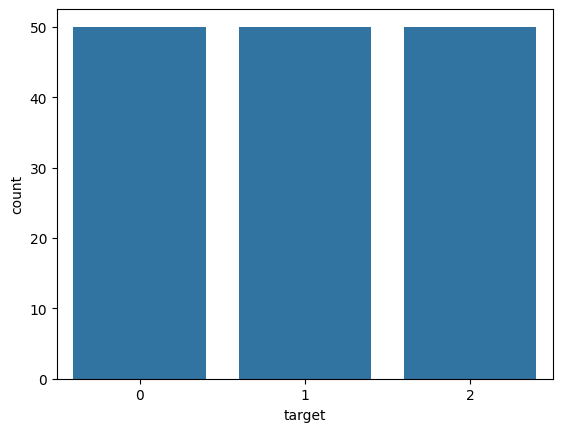

In [10]:
# countplot of  target variable
sns.countplot(data=df_iris, x='target')

6.2. Кругова діаграма

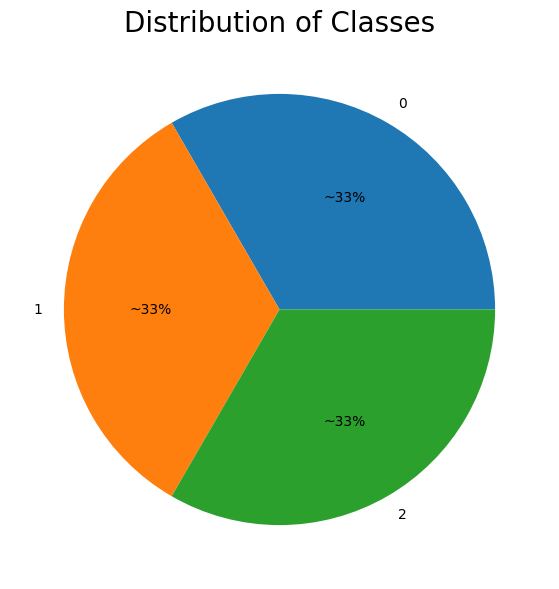

In [61]:
# Підрахунок кількості в кожному класі
# count_list = [(df_iris.target == 0).sum(), (df_iris.target == 1).sum(), (df_iris.target == 2).sum()]
count_list = df_iris['target'].value_counts()
count_list # [50,50,50]

# Отримання назв класів
lbl_list = list(df_iris['target'].unique())
lbl_list #[0, 1, 2]

# Створення фігури
plt.figure(figsize=(10,7))
plt.pie(count_list, labels=lbl_list, autopct='~%d%%') #autopct auto-calc % of val (%1.1f%% or %d%%)
plt.title("Distribution of Classes", fontsize=20)
plt.show()

7. Побудувати діаграму розподілу значень для кожної ознаки.

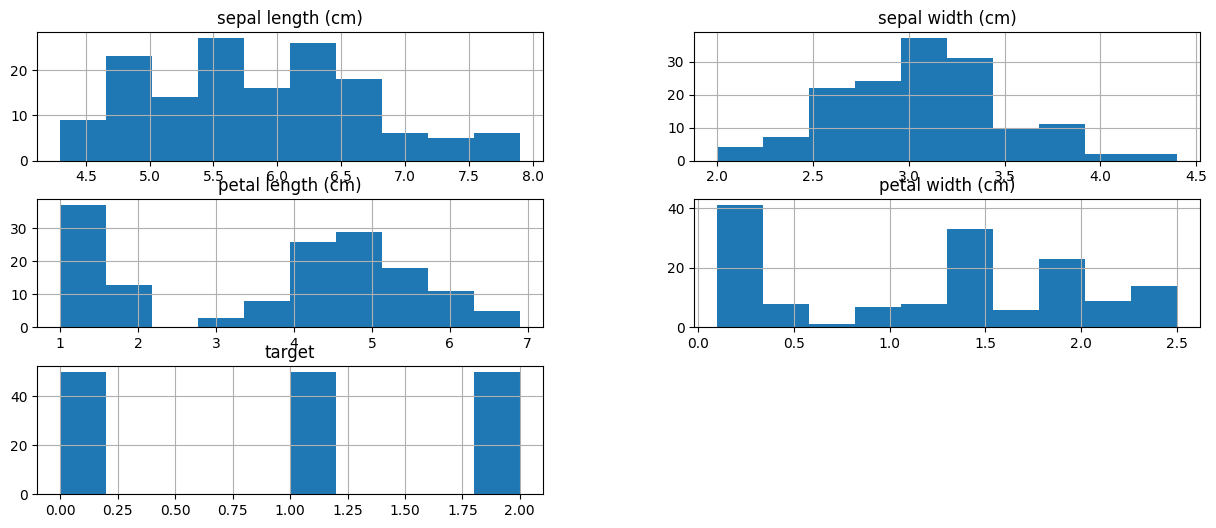

In [65]:
# Histogram showing num of samples per feature
df_iris.hist()
fig=plt.gcf()
fig.set_size_inches(15,6)
plt.show()

8. Побудувати точкову діаграму розсіяння (scatterplot) спостережень за класами. Для цього можна використати, наприклад, функцію pairplot з бібліотеки Seaborn.

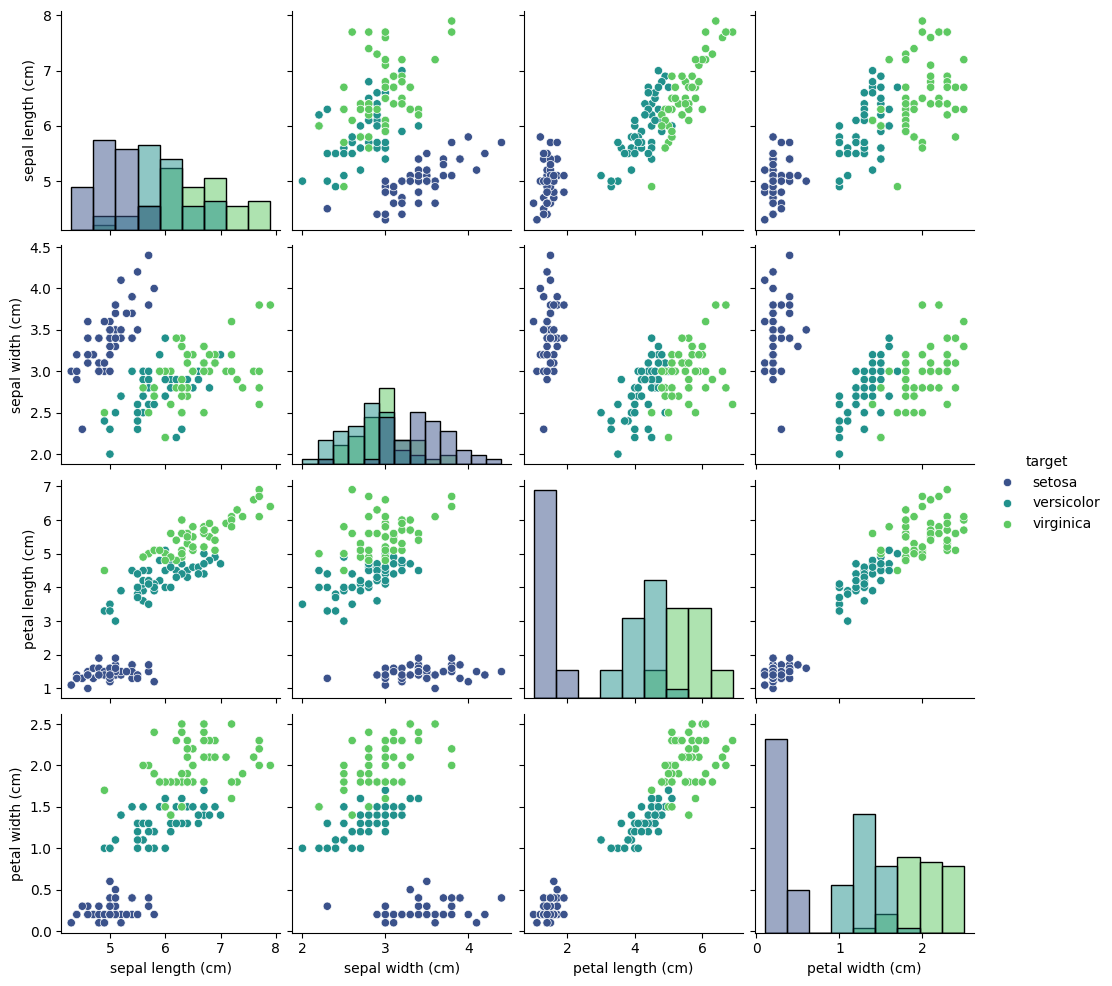

In [ ]:
sns.pairplot(df_iris, hue='target', palette='viridis', diag_kind='hist')
# hue - color by target (each class diff color)
# palette: viridis, Set2, husl, deep, colorblind, tab10, Paired, Pastel1, Dark2, Accent
# diag_kind - type of plot on diagonal (hist, kde, auto)

9. Побудувати кореляційну матрицю набору даних. Для цього використайте метод corr() бібліотеки Pandas.

In [46]:
corr_mx = df_iris.corr()

10. Візуалізація отриманої кореляційної матриці засобами функції heatmap() бібліотеки Seaborn.

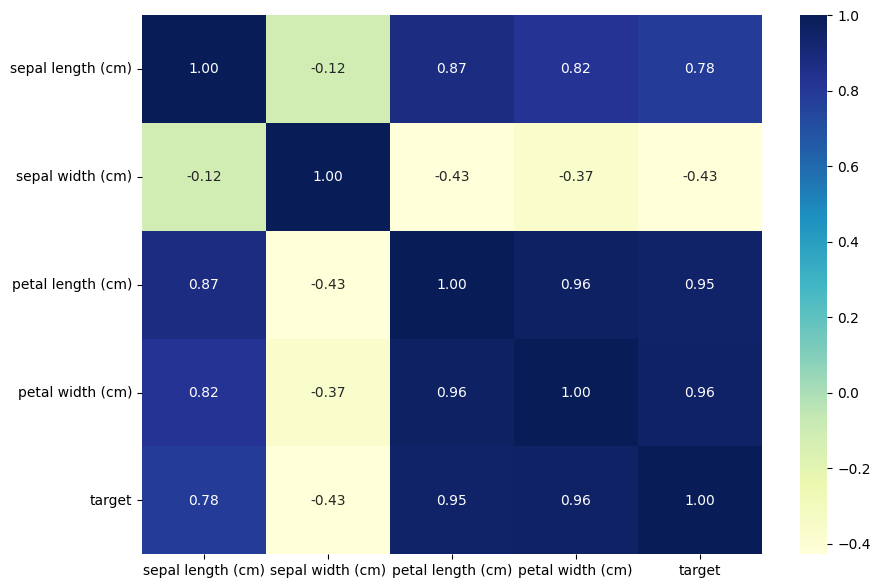

In [48]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_mx, annot=True, fmt='.2f', cmap='YlGnBu') #fmt(format=floating point number) cmap(YellowGreenBlue)
plt.show()

11. Висновок про придатність вибраних ознак з точки зору подальшої класифікації.
Аналіз точкової діаграми розсіяння спостережень за класами та знайти ознаки, у яких спостереження різних класів є розділеними.

Базуючись на точковій діаграмі розподілу спостережень за класами та кореляційній матриці, можна зробити висновок, що найбільш перспективними з точки зору подальшої класифікації ознаками є:
- petal length
- petal width